# Predviđanje otkazivanja članstva u teretani

Reproducibilan eksperiment uz članak na [peremin.com](https://www.peremin.com/).

**Važno:** podaci su sintetički. Ne predstavljaju stvarne članove, stvarnu teretanu ni dokaz da će isti model raditi na tuđim podacima. Generator samo stvara uvjerljive odnose kako bismo demonstrirali ispravan analitički postupak bez objave osobnih podataka.

Notebook koristi vremenski split, uspoređuje jednostavno poslovno pravilo s dva modela i mjeri ono što je operativno korisno: koliko je stvarnih budućih odlazaka među 10% članova s najvećim rizikom.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, brier_score_loss, precision_score,
    recall_score, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 46
DATA_PATH = Path("gym_members_churn_synthetic.csv")
CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Generiranje podataka

Generator namjerno ugrađuje obrasce koje je razumno očekivati u subscription poslu: pad posjeta, dulju neaktivnost, probleme s plaćanjem, neodrađen onboarding i učestala otkazivanja rezervacija. Tu nema čarolije — cilj je dobiti kontrolirani poligon za postupak, a ne fabricirati tržišnu istinu.

In [2]:
def sigmoid(value: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-value))


def make_gym_data(rows: int = 12_000, seed: int = SEED) -> pd.DataFrame:
    """Create anonymous member snapshots with realistic relationships, not real people."""
    rng = np.random.default_rng(seed)
    snapshot_months = pd.date_range("2024-01-01", "2025-12-01", freq="MS")
    snapshot_date = rng.choice(snapshot_months, rows)
    tenure_months = np.clip(rng.gamma(2.2, 8.5, rows).astype(int) + 1, 1, 72)
    plan_type = rng.choice(["monthly", "annual", "flex"], rows, p=[0.48, 0.34, 0.18])
    acquisition_channel = rng.choice(
        ["organic", "paid_social", "referral", "walk_in", "corporate"],
        rows,
        p=[0.25, 0.23, 0.20, 0.17, 0.15],
    )
    onboarding_completed = rng.binomial(
        1, np.clip(0.68 + 0.12 * (acquisition_channel == "referral"), 0, 0.95)
    )
    latent_engagement = np.clip(
        rng.beta(2.4, 2.1, rows)
        + 0.10 * onboarding_completed
        + 0.08 * (acquisition_channel == "referral"),
        0,
        1,
    )
    visits_prev_30d = np.clip(
        rng.poisson(1.2 + 8.2 * latent_engagement), 0, 24
    )
    disengaging = rng.binomial(
        1,
        sigmoid(
            -1.55
            + 0.85 * (tenure_months <= 3)
            + 0.45 * (plan_type == "monthly")
            - 0.55 * onboarding_completed
            - 0.65 * latent_engagement
        ),
    )
    visit_drop = disengaging * rng.integers(1, 7, rows)
    visits_30d = np.clip(
        visits_prev_30d + rng.integers(-2, 3, rows) - visit_drop, 0, 24
    )
    visit_change_30d = visits_30d - visits_prev_30d
    days_since_last_visit = np.clip(
        rng.gamma(1.4, 2.0 + 16 / (visits_30d + 1)) + 7 * disengaging,
        0,
        60,
    ).round().astype(int)
    app_sessions_30d = np.clip(
        rng.poisson(0.8 + 5.5 * latent_engagement - 0.5 * disengaging), 0, 25
    )
    classes_booked_30d = np.clip(
        rng.poisson(0.3 + 3.1 * latent_engagement), 0, 12
    )
    cancellation_probability = np.clip(
        0.06 + 0.28 * disengaging + 0.08 * (plan_type == "flex"), 0, 0.75
    )
    classes_cancelled_30d = np.array(
        [
            rng.binomial(booked, probability)
            for booked, probability in zip(
                classes_booked_30d, cancellation_probability, strict=True
            )
        ]
    )
    class_cancel_rate = np.divide(
        classes_cancelled_30d,
        classes_booked_30d,
        out=np.zeros(rows),
        where=classes_booked_30d > 0,
    ).round(3)
    pt_sessions_90d = np.clip(
        rng.poisson(
            0.15
            + 0.9 * onboarding_completed
            + 0.7 * (plan_type == "annual")
            + 0.4 * latent_engagement
        ),
        0,
        8,
    )
    payment_failures_90d = np.clip(
        rng.poisson(0.035 + 0.08 * (plan_type == "monthly")), 0, 2
    )
    referred_friend = rng.binomial(
        1, np.clip(0.04 + 0.16 * latent_engagement, 0, 0.35)
    )
    monthly_fee_eur = np.select(
        [plan_type == "annual", plan_type == "flex"],
        [rng.normal(36, 3, rows), rng.normal(49, 4, rows)],
        default=rng.normal(43, 3.5, rows),
    ).round(2)
    support_tickets_90d = np.clip(
        rng.poisson(0.12 + 0.20 * payment_failures_90d), 0, 4
    )

    churn_logit = (
        -3.55
        + 0.075 * days_since_last_visit
        - 0.12 * visits_30d
        - 0.095 * visit_change_30d
        - 0.065 * app_sessions_30d
        + 0.75 * class_cancel_rate
        + 1.15 * payment_failures_90d
        + 0.40 * support_tickets_90d
        + 0.55 * (tenure_months <= 3)
        + 0.40 * (plan_type == "monthly")
        + 0.18 * (plan_type == "flex")
        - 0.55 * onboarding_completed
        - 0.42 * referred_friend
        - 0.12 * pt_sessions_90d
        + rng.normal(0, 0.55, rows)
    )
    churn_next_30d = rng.binomial(1, sigmoid(churn_logit))

    return (
        pd.DataFrame(
            {
                "member_id": [f"GYM-{number:05d}" for number in range(1, rows + 1)],
                "snapshot_date": pd.to_datetime(snapshot_date),
                "tenure_months": tenure_months,
                "plan_type": plan_type,
                "acquisition_channel": acquisition_channel,
                "monthly_fee_eur": monthly_fee_eur,
                "onboarding_completed": onboarding_completed,
                "visits_prev_30d": visits_prev_30d,
                "visits_30d": visits_30d,
                "visit_change_30d": visit_change_30d,
                "days_since_last_visit": days_since_last_visit,
                "app_sessions_30d": app_sessions_30d,
                "classes_booked_30d": classes_booked_30d,
                "classes_cancelled_30d": classes_cancelled_30d,
                "class_cancel_rate": class_cancel_rate,
                "pt_sessions_90d": pt_sessions_90d,
                "payment_failures_90d": payment_failures_90d,
                "support_tickets_90d": support_tickets_90d,
                "referred_friend": referred_friend,
                "churn_next_30d": churn_next_30d,
            }
        )
        .sort_values(["snapshot_date", "member_id"])
        .reset_index(drop=True)
    )



data = make_gym_data()
data.to_csv(DATA_PATH, index=False)
print(f"Redaka: {len(data):,}")
print(f"Churn stopa: {data.churn_next_30d.mean():.1%}")
data.head()

Redaka: 12,000
Churn stopa: 4.4%


,member_id,snapshot_date,tenure_months,plan_type,acquisition_channel,monthly_fee_eur,onboarding_completed,visits_prev_30d,visits_30d,visit_change_30d,days_since_last_visit,app_sessions_30d,classes_booked_30d,classes_cancelled_30d,class_cancel_rate,pt_sessions_90d,payment_failures_90d,support_tickets_90d,referred_friend,churn_next_30d
0,GYM-00046,2024-01-01,14,monthly,organic,44.90,0,4,3,-1,18,0,2,0,0.0,0,0,0,0,1
1,GYM-00053,2024-01-01,22,annual,referral,37.14,1,8,9,1,11,5,2,0,0.0,2,0,0,0,0
2,GYM-00183,2024-01-01,31,monthly,referral,48.24,1,8,6,-2,9,5,3,0,0.0,2,0,0,0,0
3,GYM-00184,2024-01-01,7,flex,referral,45.67,0,5,4,-1,1,6,3,0,0.0,0,0,1,0,0
4,GYM-00192,2024-01-01,5,monthly,paid_social,42.25,0,7,7,0,1,3,1,0,0.0,0,0,0,0,0


In [3]:
assert data["member_id"].is_unique
assert data["churn_next_30d"].isin([0, 1]).all()
assert data.isna().sum().sum() == 0
assert data["snapshot_date"].min() == pd.Timestamp("2024-01-01")
assert data["snapshot_date"].max() == pd.Timestamp("2025-12-01")
print("Sanity check prošao.")

Sanity check prošao.


## 2. Vremenski split, bez gledanja u budućnost

Treniramo na snapshotima do kolovoza 2025., a testiramo na zadnja četiri mjeseca. Random split bi dao ljepši broj i slabiju priču: u stvarnosti uvijek predviđamo budućnost iz prošlosti.

In [4]:
FEATURES = [
    "tenure_months", "plan_type", "acquisition_channel", "monthly_fee_eur",
    "onboarding_completed", "visits_prev_30d", "visits_30d",
    "visit_change_30d", "days_since_last_visit", "app_sessions_30d",
    "classes_booked_30d", "classes_cancelled_30d", "class_cancel_rate",
    "pt_sessions_90d", "payment_failures_90d", "support_tickets_90d",
    "referred_friend"
]
CATEGORICAL = ["plan_type", "acquisition_channel"]
NUMERIC = [column for column in FEATURES if column not in CATEGORICAL]

train = data[data["snapshot_date"] < "2025-09-01"].copy()
test = data[data["snapshot_date"] >= "2025-09-01"].copy()
X_train, y_train = train[FEATURES], train["churn_next_30d"]
X_test, y_test = test[FEATURES], test["churn_next_30d"]

print(f"Train: {len(train):,} | Test: {len(test):,}")
print(f"Train churn: {y_train.mean():.1%} | Test churn: {y_test.mean():.1%}")

Train: 9,976 | Test: 2,024
Train churn: 4.4% | Test churn: 4.4%


## 3. Pravilo prije modela

Ako osoba nije došla 14 dana, označi je rizičnom. To je banalno, jeftino i potpuno legitimno. Model mora pobijediti nešto što bi pametan voditelj teretane mogao složiti u Excelu prije prve kave.

In [5]:
baseline = (X_test["days_since_last_visit"] >= 14).astype(int)
baseline_metrics = {
    "roc_auc": roc_auc_score(y_test, baseline),
    "pr_auc": average_precision_score(y_test, baseline),
    "precision": precision_score(y_test, baseline, zero_division=0),
    "recall": recall_score(y_test, baseline, zero_division=0),
}
pd.Series(baseline_metrics).round(3)

roc_auc      0.749
pr_auc       0.126
precision    0.171
recall       0.644
dtype: float64

## 4. Dva modela, bez zoološkog vrta algoritama

In [6]:
prepare = ColumnTransformer([
    ("numeric", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), NUMERIC),
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
])

models = {
    "Logistic regression": Pipeline([
        ("prepare", prepare),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random forest": Pipeline([
        ("prepare", prepare),
        ("model", RandomForestClassifier(
            n_estimators=250, min_samples_leaf=18,
            class_weight="balanced_subsample", n_jobs=-1, random_state=SEED
        )),
    ]),
}

In [7]:
def top_fraction_metrics(y_true, probability, fraction=0.10):
    cutoff = max(1, int(len(y_true) * fraction))
    selected = np.argsort(probability)[-cutoff:]
    precision = y_true.iloc[selected].mean()
    recall = y_true.iloc[selected].sum() / y_true.sum()
    return float(precision), float(recall)

rows, probabilities = [], {}
for name, model in models.items():
    model.fit(X_train, y_train)
    probability = model.predict_proba(X_test)[:, 1]
    probabilities[name] = probability
    precision_10, recall_10 = top_fraction_metrics(y_test, probability)
    rows.append({
        "model": name,
        "roc_auc": roc_auc_score(y_test, probability),
        "pr_auc": average_precision_score(y_test, probability),
        "precision_top_10pct": precision_10,
        "recall_top_10pct": recall_10,
        "brier": brier_score_loss(y_test, probability),
    })

metrics = pd.DataFrame(rows).set_index("model")
metrics.round(3)

,roc_auc,pr_auc,precision_top_10pct,recall_top_10pct,brier
model,,,,,
Logistic regression,0.863,0.431,0.262,0.589,0.136
Random forest,0.852,0.359,0.248,0.556,0.080


## 5. Risk decili i signali

Dobar ranking mora pokazati sve veću stvarnu churn stopu kako idemo od najnižeg prema najvišem risk decilu. Koeficijenti logističke regresije daju nam i smjer signala. To nije kauzalno objašnjenje, ali je bolji početak od slijepog dashboarda.

In [8]:
best_name = metrics["precision_top_10pct"].idxmax()
scored = test[["member_id", "churn_next_30d"]].copy()
scored["risk"] = probabilities[best_name]
scored["risk_decile"] = pd.qcut(scored["risk"], 10, labels=range(1, 11))
deciles = scored.groupby("risk_decile", observed=True)["churn_next_30d"].mean()
(deciles * 100).round(1).rename("churn_rate_pct").to_frame()

,churn_rate_pct
risk_decile,
1,0.0
2,0.5
3,0.5
4,1.5
5,1.0
6,2.5
7,1.5
8,5.4
9,5.4


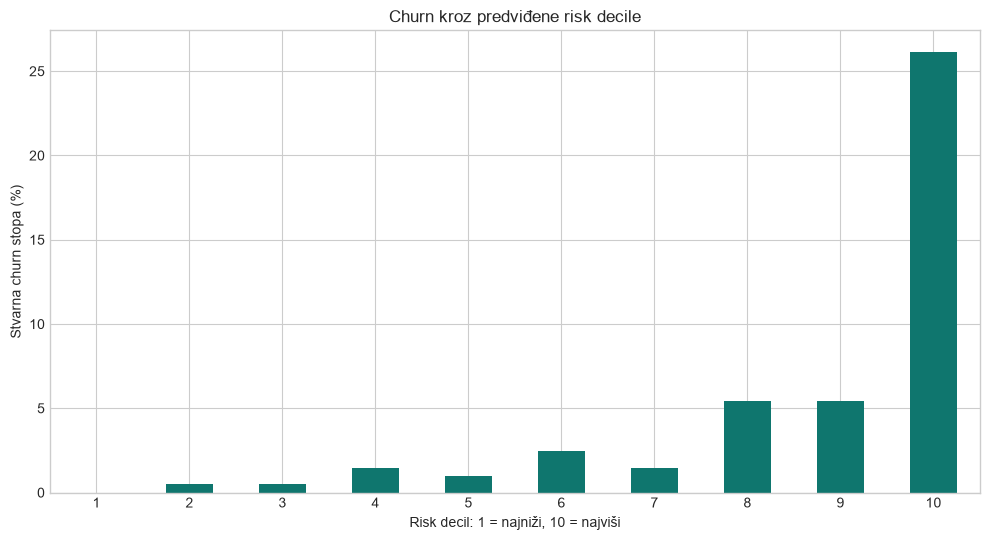

In [9]:
ax = (deciles * 100).plot(kind="bar", figsize=(10, 5.5), color="#0f766e")
ax.set_ylabel("Stvarna churn stopa (%)")
ax.set_xlabel("Risk decil: 1 = najniži, 10 = najviši")
ax.set_title("Churn kroz predviđene risk decile")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "risk-deciles.png", dpi=170)
plt.show()

In [10]:
logistic = models["Logistic regression"]
feature_names = logistic.named_steps["prepare"].get_feature_names_out()
coefficients = pd.Series(
    logistic.named_steps["model"].coef_[0], index=feature_names
)
strongest = coefficients.loc[coefficients.abs().nlargest(12).index].sort_values()
strongest.rename(lambda x: x.replace("numeric__", "").replace("categorical__", "").replace("_", " ")).round(3)

plan type flex                  -0.313
onboarding completed            -0.295
visits 30d                      -0.239
visit change 30d                -0.215
referred friend                 -0.202
app sessions 30d                -0.199
acquisition channel walk in     -0.183
visits prev 30d                 -0.148
acquisition channel corporate   -0.135
class cancel rate                0.193
payment failures 90d             0.438
days since last visit            0.693
dtype: float64

## 6. Poslovni scenarij, ne obećanje

Pretpostavimo da teretana kontaktira 10% najrizičnijih članova. Donji izračun **ne dokazuje** da će poruka ili ponuda nekoga zadržati. Samo pokazuje koliku bi ekonomsku vrijednost imao eksperiment uz zadane pretpostavke. Učinak intervencije mora se izmjeriti randomiziranim holdoutom.

In [11]:
precision_10 = metrics.loc[best_name, "precision_top_10pct"]
members_scored = 1_000
members_contacted = int(members_scored * 0.10)
expected_true_churners = members_contacted * precision_10
assumed_save_rate = 0.20
saved_members = expected_true_churners * assumed_save_rate
contribution_margin_monthly = 33
months_retained = 6
contact_cost = 8

scenario = pd.Series({
    "Kontaktirani članovi": members_contacted,
    "Očekivani stvarni churneri u grupi": expected_true_churners,
    "Spašeni članovi uz pretpostavljenih 20%": saved_members,
    "Bruto vrijednost zadržavanja (€)": saved_members * contribution_margin_monthly * months_retained,
    "Trošak intervencije (€)": members_contacted * contact_cost,
    "Neto vrijednost prije fiksnih troškova (€)": (
        saved_members * contribution_margin_monthly * months_retained
        - members_contacted * contact_cost
    ),
})
scenario.round(1).to_frame("vrijednost")

,vrijednost
Kontaktirani članovi,100.0
Očekivani stvarni churneri u grupi,26.2
Spašeni članovi uz pretpostavljenih 20%,5.2
Bruto vrijednost zadržavanja (€),1039.0
Trošak intervencije (€),800.0
Neto vrijednost prije fiksnih troškova (€),239.0


## Zaključak

- Churn model služi za prioritizaciju, ne za automatsko dijeljenje popusta.
- Vremenski split je obavezan.
- Precision među članovima koje stvarno možemo kontaktirati važniji je od gole accuracy metrike.
- Visok rizik ne znači da je osoba uvjerljiva. Za to trebaju eksperiment i uplift model.
- Sintetički rezultat je demonstracija pipelinea. Prava odluka počinje tek na stvarnim, zakonito prikupljenim podacima.